In [70]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import h5py
import re
import seaborn as sns
from math import pi 
from scipy.spatial import cKDTree
from matplotlib.colors import Normalize

f5 = '/Users/lilywatanabe/Desktop/eth/thesis/SPH-EXA-fork/output/run_disk_1J_5000.hdf5'
f5_double = '/Users/lilywatanabe/Desktop/eth/thesis/SPH-EXA-fork/output/run_disk_2J_5000.hdf5'
f5_half = '/Users/lilywatanabe/Desktop/eth/thesis/SPH-EXA-fork/output/run_disk_05J_5000.hdf5'
plots = '/Users/lilywatanabe/Desktop/eth/thesis/SPH-EXA-fork/output/plots/'

# constants
G = 1 
G2 = G * G
alpha = 0.4

In [71]:
# extract data from hdf5 file with optional stride 
# returns arrays of selected keys (based on stride), density, pressure, x, y and z coords of particles & star
def read_hdf5_data(file, stride=1):
    densities = []
    pressures = []
    masses = []
    x_pos = []
    y_pos = []
    z_pos = []
    h = []
    c = []
    times = []
    star_x = []
    star_y = []
    star_z = []
    star_m = []

    with h5py.File(file, 'r') as f: 
        step_keys = sorted(f.keys(), key=lambda x: int(re.search(r'\d+', x).group()))
        selected_keys = step_keys[::stride]
        
        # extract all star mass and sound speed data
        for step_key in selected_keys:
            densities.append(np.array(f[step_key]['rho']))
            pressures.append(np.array(f[step_key]['p']))
            masses.append(np.array(f[step_key]['m']))
            x_pos.append(np.array(f[step_key]['x']))
            y_pos.append(np.array(f[step_key]['y']))
            z_pos.append(np.array(f[step_key]['z']))
            h.append(np.array(f[step_key]['h']))
            c.append(np.array(f[step_key]['c']))
            times.append(np.array(f[step_key].attrs['time']))
            star_x.append(np.array(f[step_key].attrs['star::x']))
            star_y.append(np.array(f[step_key].attrs['star::y']))
            star_z.append(np.array(f[step_key].attrs['star::z']))
            star_m.append(np.array(f[step_key].attrs['star::m']))

    return selected_keys, densities, pressures, masses, x_pos, y_pos, z_pos, h, c, times, star_x, star_y, star_z, star_m

In [72]:
# shortened version  
def particle_radii2(x, y, z, m, star_x, star_y, star_z, star_m, timesteps): 
    num_timesteps = len(timesteps)
    radii = []
    disk_particles = []

    for step in range(num_timesteps):
        nr_particles = len(x[step])  
        step_radii = np.zeros(nr_particles) 
        step_disk_particles = np.zeros(nr_particles, dtype=bool)
        
        # calculate the radii for each particle at this step
        step_radii[:] = np.sqrt((x[step] - star_x[step])**2 + 
                                 (y[step] - star_y[step])**2 + 
                                 (z[step] - star_z[step])**2)
        # print("step radius: ", step_radii, "\n")
        # mark disk particles based on the threshold
        threshold_radius = 2.0*2.5
        step_disk_particles[:] = step_radii < threshold_radius

        inner_disk_count = np.sum(step_disk_particles)
        #print(f"timestep {timesteps[step]}, {inner_disk_count} particles in disk, {nr_particles} total particles")

        radii.append(step_radii)
        disk_particles.append(step_disk_particles)
    #print("len of radii: ", len(radii), " len of disk_particles: ", len(disk_particles))
    return radii, disk_particles

In [73]:
# Kernel function according to paper
def W(r, h, sigma=10/7*pi):
    q = r/h 
    if 0 <= q <= 1: 
        return (sigma / h**2) * (1 - 1.5 * q**2 + 0.75 * q**3)
    elif 1 < q <= 2: 
        return (sigma / h**2) * 0.25*(2 - q)**3
    else: 
        return 0

# calculate surface density at timestep t for all particles 
def surface_density(t, rho, x, y, h, m, disk_mask, stride): 
    index = int(t/stride)
    rho_disk = rho[index][disk_mask[index]]
    h_disk = h[index][disk_mask[index]]
    x_disk = x[index][disk_mask[index]]
    y_disk = y[index][disk_mask[index]]
    m_disk = m[index][disk_mask[index]]
    num_particles = len(x_disk)

    surface_density = np.zeros(num_particles)
    positions = np.column_stack((x_disk, y_disk))
    tree = cKDTree(positions)

    for j in range(1, num_particles):
        density = 0.0

        indices = tree.query_ball_point(positions[j], h_disk[j])
        for i in indices: 
            if i != j: 
                r_ij = np.linalg.norm(positions[j] - positions[i])
                W_ij = W(r_ij, h_disk[i])
                density += m_disk[i] * W_ij
        surface_density[j] = density
    return surface_density

In [74]:
def calc_accretion_rate(masses, times, c_s): 
    accretion_rate = []
    analytical_all = []
    for i in range(1, len(masses)): 
        delta_t = (times[i] - times[i - 1])
        if delta_t != 0: 
            rate_i = (masses[i] - masses[i - 1]) / delta_t
        else:
            rate_i = np.nan
        accretion_rate.append(rate_i)
        # print("all: ", len(c_s[i]))
        analytical_all.append(alpha * ((np.mean(c_s[i])**3) / G))
    return accretion_rate, analytical_all

def calc_analytical_rate(c_s, disk_mask, stride): 
    analytical_rate = []
    c_disk = []
    for t in range(1, len(c_s)):
        c_disk_t = c_s[t][disk_mask[t]]
        # print("disk: ", len(c_disk_t))
        c_disk.append(np.mean(c_disk_t))
    for i in range(0, len(c_disk)): 
        analytical_rate.append(alpha * ((c_disk[i]**3) / G))
    return analytical_rate

In [75]:
def plot_density(t, x, y, z, star_x, star_y, star_z, densities, disk_mask):
    x_disk = x[t][disk_mask[t]]
    y_disk = y[t][disk_mask[t]]
    z_disk = z[t][disk_mask[t]]
    densities_disk = densities[t][disk_mask[t]]
    #print("Filtered X values:", x_disk)
    #print("Filtered Y values:", y_disk)
    #print("Filtered Z values:", z_disk)
    print("Filtered Densities:", len(densities_disk))
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x_disk, y_disk, z_disk, c=densities_disk, cmap='viridis', s=1)
    plt.colorbar(scatter, label='Density')
    ax.plot(star_x[t], star_y[t], star_z[t], color = 'red')
    ax.set_title(f'Density Distribution in 3D at timestep {t}')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Z Position')
    ax.set_xlim([np.min(x_disk), np.max(x_disk)])
    ax.set_ylim([np.min(y_disk), np.max(y_disk)])
    ax.set_zlim([np.min(z_disk), np.max(z_disk)])
    fname = f'density_distribution_1J.png'
    plt.savefig(plots + fname)
    plt.show()

In [76]:
def plot_radial_density(t, r, densities, disk_mask, times, stride): 
    r_disk = r[int(t/stride)][disk_mask[int(t/stride)]]
    densities_disk = densities[int(t/stride)][disk_mask[int(t/stride)]]
    nr_particles = len(r_disk)
    r_particles = np.zeros((nr_particles, 2))
    for i in range(0, len(r_disk), 1): 
        r_particles[i][0] = r_disk[i]
        r_particles[i][1] = i
    r_particles = r_particles[np.argsort(r_particles[:, 0])]
    sorted_radii = r_particles[:, 0]
    sorted_indices = r_particles[:, 1].astype(int)
    densities_sorted = densities[int(t/stride)][disk_mask[int(t/stride)]][sorted_indices]
    #for i in range(0, len(r_disk), 1): 
    #   densities_sorted.append(densities[r_particles[i][1]])

    plt.figure()
    plt.scatter(sorted_radii, densities_sorted, label='density at radius r', color='blue', marker='.')
    plt.title(f'Particle density at Radius R at timestep {t}')
    plt.xlabel('Radius')
    plt.ylabel('Density')
    plt.grid()
    plt.legend()
    fname = f'radial_density_1J.png'
    plt.savefig(plots + fname)
    plt.show()

In [77]:
def plot_pressure(t, x, y, z, star_x, star_y, star_z, pressures, disk_mask, stride):
    x_disk = x[int(t/stride)][disk_mask[int(t/stride)]]
    y_disk = y[int(t/stride)][disk_mask[int(t/stride)]]
    z_disk = z[int(t/stride)][disk_mask[int(t/stride)]]
    pressures_disk = pressures[int(t/stride)][disk_mask[int(t/stride)]]
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x_disk, y_disk, z_disk, c=pressures_disk, cmap='viridis', s=1)
    plt.colorbar(scatter, label='Pressure')
    ax.plot(star_x[t], star_y[t], star_z[t], color = 'red')

    ax.set_title(f'Pressure Distribution in 3D at timestep {t}')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Z Position')
    ax.set_xlim([np.min(x_disk), np.max(x_disk)])
    ax.set_ylim([np.min(y_disk), np.max(y_disk)])
    ax.set_zlim([np.min(z_disk), np.max(z_disk)])
    fname = f'pressure_distribution_1J.png'
    plt.savefig(plots + fname)
    plt.show()

In [78]:
def plot_radial_density_multiple_timesteps(timesteps, r, densities, disk_mask, stride, num_bins=20):
    plt.figure()

    for t in timesteps:
        index = int(t/stride)
        print(stride, " ", index, "\n")
        r_disk = r[index][disk_mask[index]]
        densities_disk = densities[index][disk_mask[index]]

        # bins for radii
        r_min, r_max = np.min(r_disk), np.max(r_disk)
        bins = np.linspace(r_min, r_max, num_bins + 1) 
        bin_centers = 0.5 * (bins[:-1] + bins[1:])  

        # average density in each bin
        average_densities = np.zeros(num_bins)
        counts = np.zeros(num_bins) 

        for i in range(len(r_disk)):
            bin_index = np.digitize(r_disk[i], bins) - 1  # -1 to get the index in zero-based format
            if 0 <= bin_index < num_bins:  # check if bin_index is within valid range
                average_densities[bin_index] += densities_disk[i]
                counts[bin_index] += 1

        average_densities /= counts
        average_densities[counts == 0] = np.nan  # set bins with no particles to NaN for better plotting

        plt.plot(bin_centers, average_densities, label=f'Timestep {t}', marker='o')

    plt.title('Average Particle density at Radius R over Multiple Timesteps')
    plt.xlabel('Radius')
    plt.ylabel('Average density')
    plt.grid()
    plt.legend()
    fname = 'radial_density_avg_multiple_timesteps.png'
    plt.savefig(plots + fname)  
    plt.show()

In [79]:
def plot_radial_pressure(t, r, pressures, disk_mask, times, stride): 
    r_disk = r[int(t/stride)][disk_mask[int(t/stride)]]
    pressures_disk = pressures[int(t/stride)][disk_mask[int(t/stride)]]
    nr_particles = len(r_disk)
    r_particles = np.zeros((nr_particles, 2))
    for i in range(0, len(r_disk), 1): 
        r_particles[i][0] = r_disk[i]
        r_particles[i][1] = i
    r_particles = r_particles[np.argsort(r_particles[:, 0])]
    sorted_radii = r_particles[:, 0]
    sorted_indices = r_particles[:, 1].astype(int)
    pressures_sorted = pressures[int(t/stride)][disk_mask[int(t/stride)]][sorted_indices]
    #for i in range(0, len(r_disk), 1): 
    #   pressures_sorted.append(pressures[r_particles[i][1]])

    plt.figure()
    plt.scatter(sorted_radii, pressures_sorted, label='pressure at radius r', color='blue', marker='.')
    plt.title(f'Particle pressure at Radius R at timestep {t}')
    plt.xlabel('Radius')
    plt.ylabel('pressure')
    plt.grid()
    plt.legend()
    fname = f'radial_pressure_1J.png'
    plt.savefig(plots + fname)
    plt.show()

In [80]:
def plot_radial_pressure_multiple_timesteps(timesteps, r, pressures, disk_mask, stride, num_bins=20):
    plt.figure()

    for t in timesteps:
        index = int(t/stride)
        r_disk = r[index][disk_mask[index]]
        pressures_disk = pressures[index][disk_mask[index]]

        # binning 
        r_min, r_max = np.min(r_disk), np.max(r_disk)
        bins = np.linspace(r_min, r_max, num_bins + 1)  
        bin_centers = 0.5 * (bins[:-1] + bins[1:])  

        # average pressure per bin
        average_pressures = np.zeros(num_bins)
        counts = np.zeros(num_bins)  

        for i in range(len(r_disk)):
            bin_index = np.digitize(r_disk[i], bins) - 1  # -1 to get the index in zero-based format
            if 0 <= bin_index < num_bins:  # check if bin_index is within valid range
                average_pressures[bin_index] += pressures_disk[i]
                counts[bin_index] += 1

        average_pressures /= counts
        average_pressures[counts == 0] = np.nan  # set bins with no particles to NaN for better plotting

        plt.plot(bin_centers, average_pressures, label=f'Timestep {t}', marker='o')

    plt.title('Average Particle Pressure at Radius R over Multiple Timesteps')
    plt.xlabel('Radius')
    plt.ylabel('Average Pressure')
    plt.grid()
    plt.legend()
    fname = 'radial_pressure_avg_multiple_timesteps.png'
    plt.savefig(plots + fname) 
    plt.show()


In [103]:
surface_density_min = None
surface_density_max = None

def compute_global_min_max(surface_densities):
    global global_surface_density_min, global_surface_density_max
    # Find the global min/max across all surface densities
    all_values = np.concatenate([sd.flatten() for sd in surface_densities])
    global_surface_density_min = np.min(all_values)
    global_surface_density_max = np.max(all_values)
    
def plot_surface_density(t, x, y, surface_density, disk_mask, stride, grid_size=200): 
    global surface_density_min, surface_density_max
    
    norm = Normalize(vmin=global_surface_density_min, vmax=global_surface_density_max)
    index = int(t/stride)

    x_disk = x[index][disk_mask[index]]
    y_disk = y[index][disk_mask[index]]
    # Scatter plot, with color representing the surface density
    plt.figure(figsize=(8, 6))
    #scatter = plt.scatter(x_disk, y_disk, c=surface_density, cmap="viridis", s=20, norm=norm)
    plt.hexbin(x_disk, y_disk, C=surface_density, gridsize=200, cmap='viridis', norm=norm)
    plt.hist2d(x_disk, y_disk, weights=surface_density, bins=grid_size, cmap='viridis', norm=norm)
    plt.colorbar(label='Surface Density')  # Show color scale
    plt.title(f'Surface Density at Timestep {t}')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    fname = f'surface density_1J_{t}.png'
    plt.savefig(plots + fname)
    plt.show()
    

In [87]:
def plot_mass_accretion(t, accretion_rates, analytical_all, analytical_disk):
    plt.figure()
    plt.scatter(t[1:], accretion_rates, label='Mass Accretion Rate', color='blue', marker='.')
    plt.scatter(t[1:], analytical_all, label=f'Analytical Mass Accretion Rate, alpha = {alpha} (all particles)', color='deeppink', marker='.', alpha=0.8)
    plt.scatter(t[1:], analytical_disk, label=f'Analytical Mass Accretion Rate, alpha = {alpha} (disk particles)', color='green', marker='.', alpha=0.8)
    plt.title('Mass Accretion Rate Over Time')
    plt.xlabel('Time (yr/2pi)')
    plt.ylabel('Accretion Rate')
    plt.grid()
    plt.ylim(0, 0.002)
    plt.legend()
    fname = f'inner_disk_mass_accretion.png'
    plt.savefig(plots + fname)
    plt.show()

In [83]:

stride=10
ts, d, p, m, x, y, z, h, c_s, times, sx, sy, sz, sm = read_hdf5_data(f5,stride)

In [84]:
r, disk_particles = particle_radii2(x, y, z, m, sx, sy, sz, sm, ts)

10   0 

10   100 

10   250 

10   500 



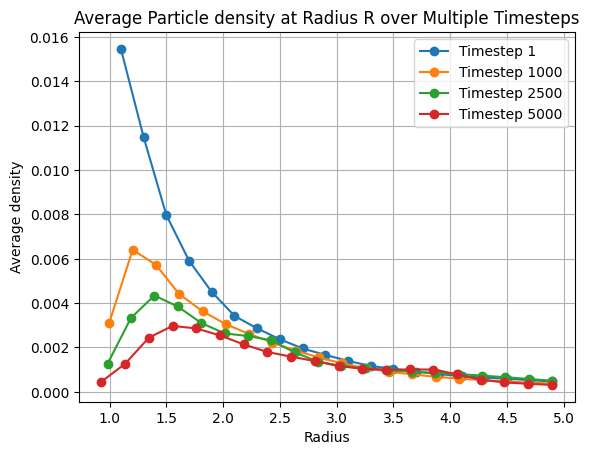

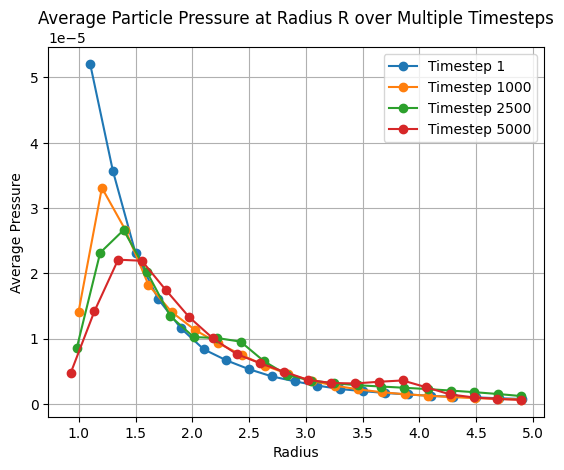

500


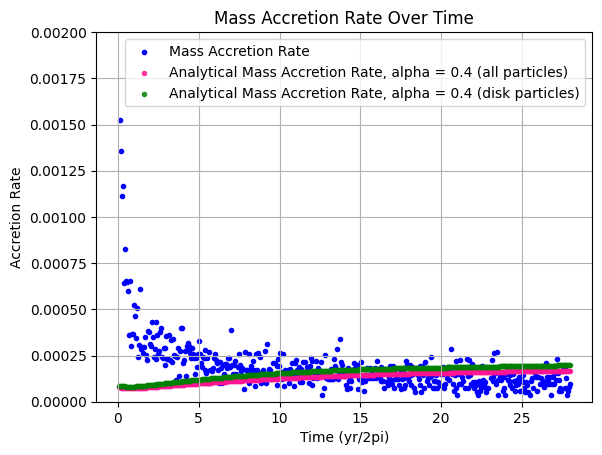

In [90]:
#plot_density(4000, x, y, z, sx, sy, sz, d, disk_particles)
#plot_pressure(4000, x, y, z, sx, sy, sz, p, disk_particles)
#plot_radial_density(4000, r, d, disk_particles, times, stride)
#plot_radial_pressure(4000, r, p, disk_particles, times, stride)
plot_radial_density_multiple_timesteps([1, 1000, 2500, 5000], r, d, disk_particles, stride)
plot_radial_pressure_multiple_timesteps([1, 1000, 2500, 5000], r, p, disk_particles, stride)
accretion_rates, analytical_all = calc_accretion_rate(sm, times, c_s)
analytical_disk = calc_analytical_rate(c_s, disk_particles, stride)
print(len(accretion_rates))
# print(len(analytical_rates))
plot_mass_accretion(times, accretion_rates, analytical_all, analytical_disk)

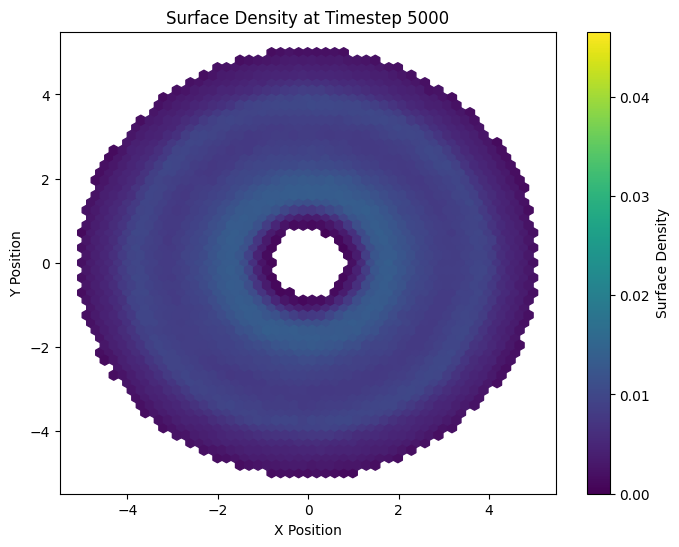

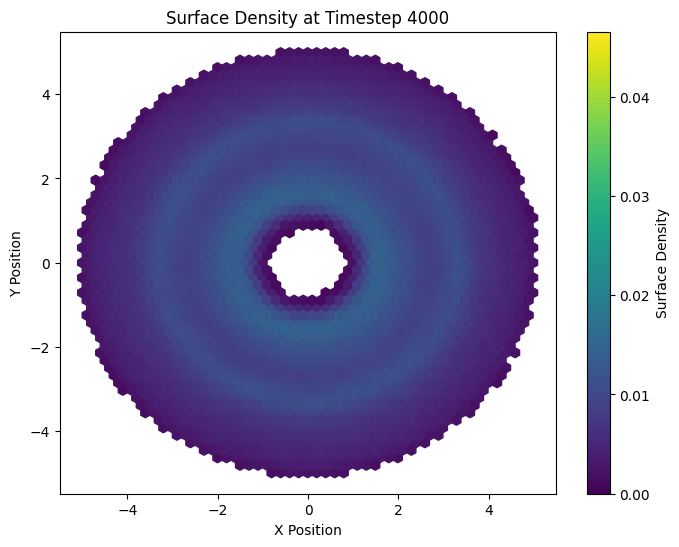

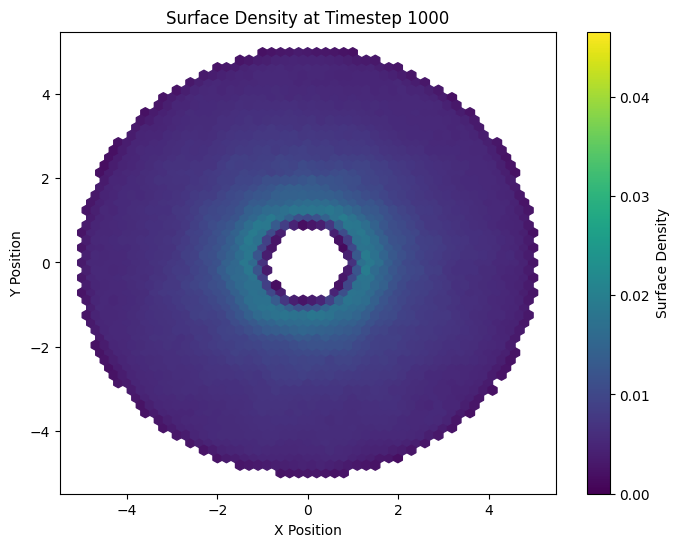

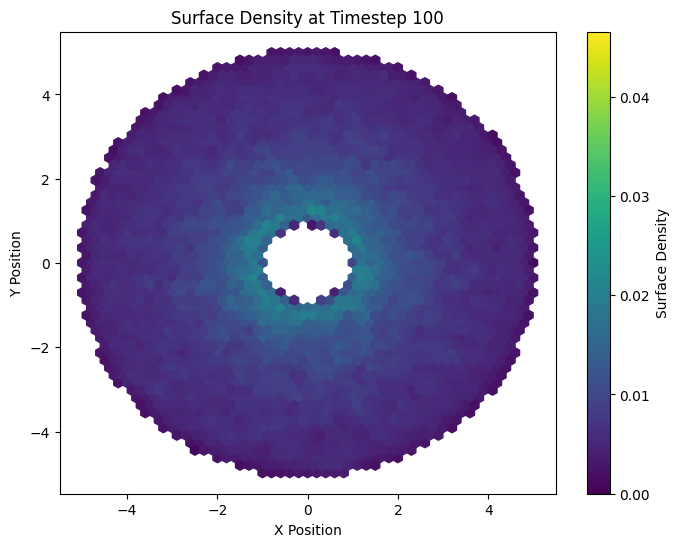

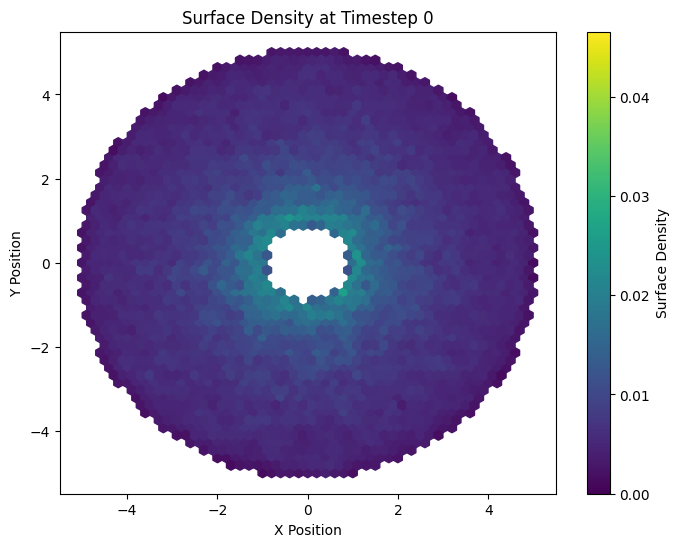

In [93]:
sig_5000 = surface_density(5000, d, x, y, h, m, disk_particles, stride)
sig_4000 = surface_density(4000, d, x, y, h, m, disk_particles, stride)
sig_1000 = surface_density(1000, d, x, y, h, m, disk_particles, stride)
sig_100 = surface_density(100, d, x, y, h, m, disk_particles, stride)
sig_0 = surface_density(0, d, x, y, h, m, disk_particles, stride)

compute_global_min_max([sig_5000, sig_4000, sig_1000, sig_100, sig_0])

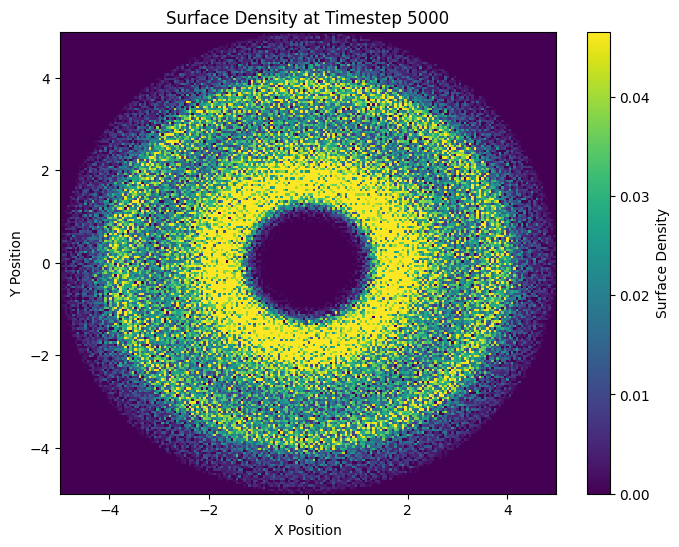

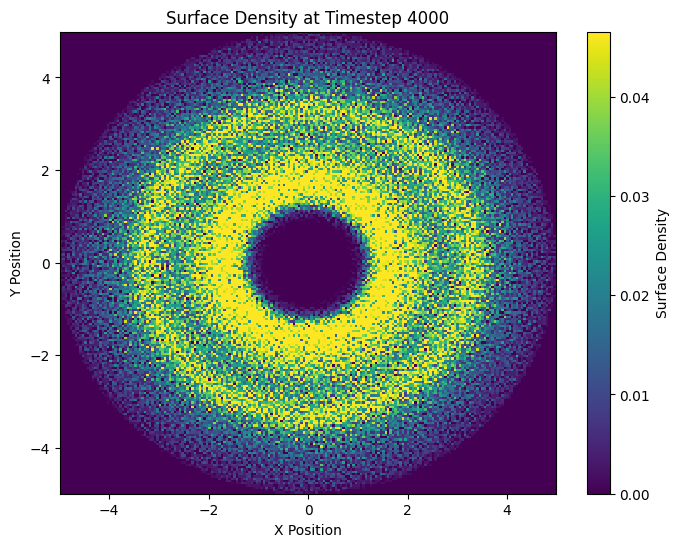

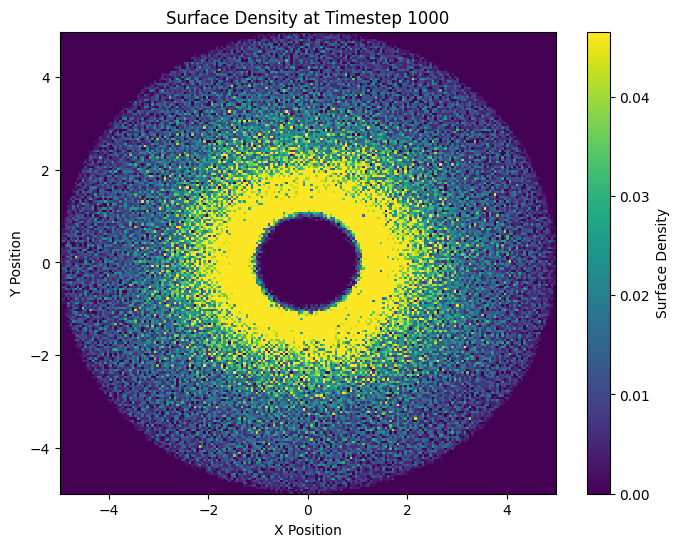

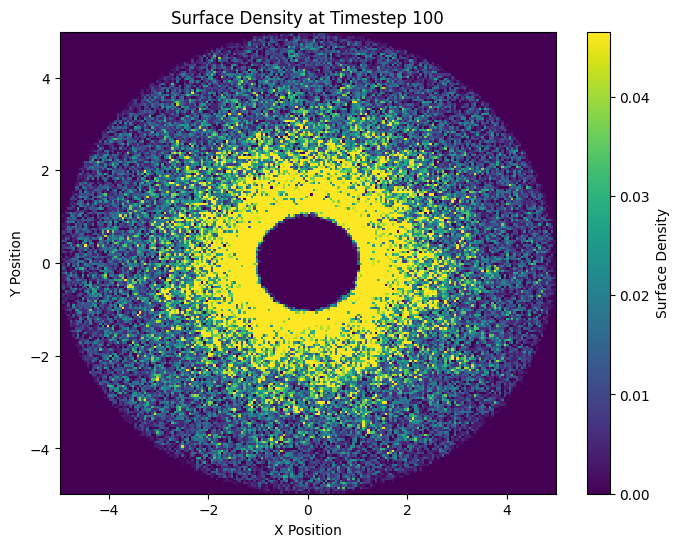

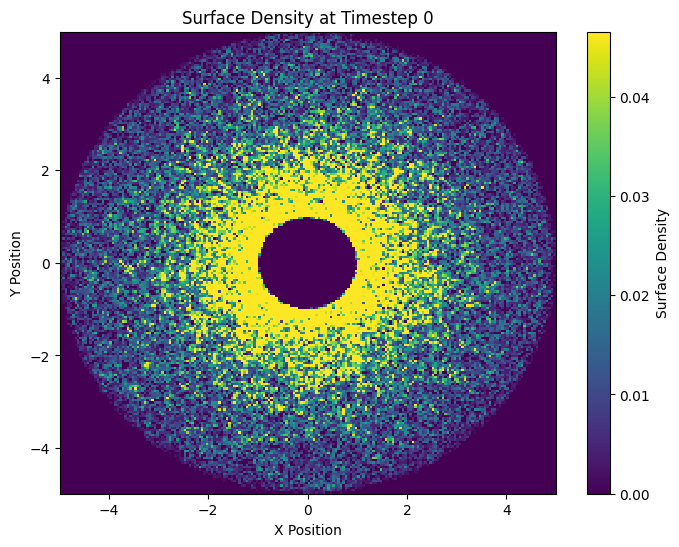

In [107]:
plot_surface_density(5000, x, y, sig_5000, disk_particles, stride)
plot_surface_density(4000, x, y, sig_4000, disk_particles, stride)
plot_surface_density(1000, x, y, sig_1000, disk_particles, stride)
plot_surface_density(100, x, y, sig_100, disk_particles, stride)
plot_surface_density(0, x, y, sig_0, disk_particles, stride)